# Loss Landscape — Single Parameter Sweep

Sweeps one `SimParams` scalar around its ground-truth value and plots the loss.

**Mode switch**: set `MODE = 'response'` (full simulated wire signals)
or `MODE = 'truth_hits'` (ideal charge-at-wire, no electronics/diffusion response).

For a **diffusion** parameter, the two modes behave very differently:
- `response` sees diffusion via the convolution kernel → bowl-shaped landscape
- `truth_hits` does **not** encode diffusion response → flat landscape

This difference makes the sweep a useful diagnostic for what each signal type is sensitive to.

In [9]:
# =============================================================================
# CONFIGURATION — edit here
# =============================================================================

CONFIG_PATH = 'config/cubic_wireplane_config.yaml'
DATA_PATH   = 'muon.h5'
EVENT_IDX   = 0

# ── Signal mode ──────────────────────────────────────────────────────────────
# 'response'   : uses simulator.forward() — requires differentiable=True + n_segments
# 'truth_hits' : uses process_event() — sensitive to velocity, lifetime, recomb
MODE = 'truth_hits'

# ── Parameter to sweep ───────────────────────────────────────────────────────
PARAM = 'lifetime_us'   # GT = 10 ms = 10_000 μs (from config)

# Sweep range: 0.5x–1.5x of default → [5000, 7500, 10000, 12500, 15000] μs
SWEEP_FRACTION_RANGE = (0.5, 1.5)
N_POINTS = 5

# ── Loss function ─────────────────────────────────────────────────────────────
# 'sobolev'  : H⁻¹ spectral norm (smooth, Wasserstein-like — recommended)
# 'blur_mse' : multi-scale Gaussian blur MSE
LOSS_TYPE = 'sobolev'

# ── Simulator knobs ──────────────────────────────────────────────────────────
TOTAL_PAD          = 200_000
RESPONSE_CHUNK     = 50_000
MAX_ACTIVE_BUCKETS = 1000
MAX_KEYS           = 2_000_000
INCLUDE_ELECTRONICS = False
INCLUDE_DIGITIZE    = True


In [10]:
# =============================================================================
# IMPORTS
# =============================================================================

import time
import gc

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from tools.simulation import DetectorSimulator
from tools.geometry import generate_detector
from tools.loader import load_event
from tools.config import create_track_hits_config
from tools.landscape import make_weights, sweep_parameter

print(f'JAX version: {jax.__version__}')
print(f'JAX devices: {jax.devices()}')

JAX version: 0.9.2
JAX devices: [CudaDevice(id=0)]


In [11]:
# =============================================================================
# SETUP SIMULATOR
# =============================================================================

detector_config = generate_detector(CONFIG_PATH)

jax.clear_caches()
gc.collect()

# Truth hits are always compiled in — needed for 'truth_hits' mode
track_config = create_track_hits_config(max_keys=MAX_KEYS)

simulator = DetectorSimulator(
    detector_config,
    use_bucketed=True,
    max_active_buckets=MAX_ACTIVE_BUCKETS,
    include_noise=False,
    include_electronics=INCLUDE_ELECTRONICS,
    include_track_hits=True,   # needed for truth_hits mode
    include_digitize=INCLUDE_DIGITIZE,
    total_pad=TOTAL_PAD,
    response_chunk_size=RESPONSE_CHUNK,
    track_config=track_config,
)
cfg = simulator.config

print(f'Loading event {EVENT_IDX} from {DATA_PATH}...')
deposits = load_event(DATA_PATH, cfg, event_idx=EVENT_IDX)
n_total = sum(v.n_actual for v in deposits.volumes)
print(f'Loaded {n_total:,} deposits')

--- Creating DetectorSimulator ---
   Extracting parameters...
   Loading response kernels...
   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=200,000, response_chunk=50,000, num_s=16, K_wire=2, K_time=6
   Using BUCKETED accumulation (max_buckets=1000)
   Digitization: ENABLED (12-bit)
   Track labeling: ENABLED
   Readout: wire
   Volumes: 2 (iterate=scan)
--- DetectorSimulator Ready ---
Loading event 0 from muon.h5...
Loaded 5,335 deposits


In [12]:
# =============================================================================
# WARM UP JIT
# =============================================================================

print('Warming up...')
t0 = time.time()
simulator.warm_up()
print(f'Done ({time.time()-t0:.1f}s)')

Warming up...
Triggering JIT compilation...
JIT compilation finished (total_pad=200,000, iterate=scan).
Done (74.6s)


In [13]:
# =============================================================================
# BUILD SWEEP GRID
# =============================================================================

base_params = simulator.default_sim_params
default_val = float(getattr(base_params, PARAM))
print(f'Default {PARAM} = {default_val:.4g}')

lo = SWEEP_FRACTION_RANGE[0] * default_val
hi = SWEEP_FRACTION_RANGE[1] * default_val
sweep_values = np.linspace(lo, hi, N_POINTS)

print(f'Sweep range: [{lo:.4g}, {hi:.4g}]  ({N_POINTS} points)')
print(f'Mode: {MODE}  |  Loss: {LOSS_TYPE}')

# Precompute spectral weights once (shape depends only on plane geometry)
print('Precomputing spectral weights...')
weights, plane_keys = make_weights(cfg, weight_type=LOSS_TYPE)
print(f'Planes: {plane_keys}')

Default lifetime_us = 1e+04
Sweep range: [5000, 1.5e+04]  (5 points)
Mode: truth_hits  |  Loss: sobolev
Precomputing spectral weights...
Planes: [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]


In [14]:
# =============================================================================
# RUN SWEEP  (one forward pass per point)
# =============================================================================

print(f'\nSweeping {PARAM} over {N_POINTS} points in {MODE} mode...')
t0 = time.time()

losses = sweep_parameter(
    simulator, deposits, base_params,
    param_name=PARAM,
    values=sweep_values,
    mode=MODE,
    weights=weights,
    cfg=cfg,
    weight_type=LOSS_TYPE,
    verbose=True,
)

elapsed = time.time() - t0
print(f'\nSweep done in {elapsed:.1f}s  ({elapsed/N_POINTS:.1f}s/point)')


Sweeping lifetime_us over 5 points in truth_hits mode...
Running ground truth (lifetime_us=1e+04)...
  [ 1/5] lifetime_us = 5000  loss = 8.0661e+05
  [ 2/5] lifetime_us = 7500  loss = 9.5610e+04
  [ 3/5] lifetime_us = 1e+04  loss = 5.2917e-11
  [ 4/5] lifetime_us = 1.25e+04  loss = 3.6262e+04
  [ 5/5] lifetime_us = 1.5e+04  loss = 1.0205e+05

Sweep done in 5.9s  (1.2s/point)


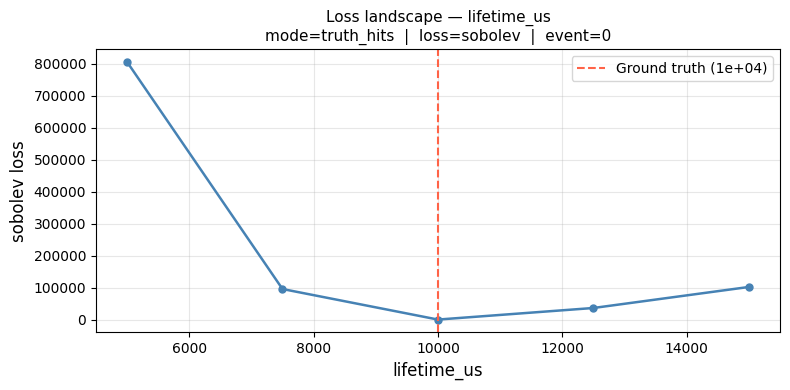

Min loss = 5.2917e-11 at lifetime_us=1e+04
GT index (closest): 2


In [15]:
# =============================================================================
# PLOT LOSS LANDSCAPE
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(sweep_values, losses, 'o-', color='steelblue', ms=5, lw=1.8)

# Mark ground truth
ax.axvline(default_val, color='tomato', ls='--', lw=1.5, label=f'Ground truth ({default_val:.3g})')

ax.set_xlabel(PARAM, fontsize=12)
ax.set_ylabel(f'{LOSS_TYPE} loss', fontsize=12)
ax.set_title(
    f'Loss landscape — {PARAM}\n'
    f'mode={MODE}  |  loss={LOSS_TYPE}  |  event={EVENT_IDX}',
    fontsize=11,
)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
import os; os.makedirs('plots', exist_ok=True)
fig.savefig(f'plots/landscape_{PARAM}_{MODE}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Min loss = {losses.min():.4e} at {PARAM}={sweep_values[losses.argmin()]:.4g}')
print(f'GT index (closest): {np.argmin(np.abs(sweep_values - default_val))}')


## Compare both modes

Re-run cells 5-7 with `MODE = 'truth_hits'` to compare the landscape.

Or run the cell below to overlay both curves in one plot.

NOTE: simulator has no _forward_diff — skipping 'response' mode.
      To enable it, add differentiable=True, n_segments=TOTAL_PAD to the constructor.

--- mode=truth_hits ---
Running ground truth (lifetime_us=1e+04)...
  [ 1/5] lifetime_us = 5000  loss = 8.0661e+05
  [ 2/5] lifetime_us = 7500  loss = 9.5610e+04
  [ 3/5] lifetime_us = 1e+04  loss = 3.4310e-11
  [ 4/5] lifetime_us = 1.25e+04  loss = 3.6262e+04
  [ 5/5] lifetime_us = 1.5e+04  loss = 1.0205e+05


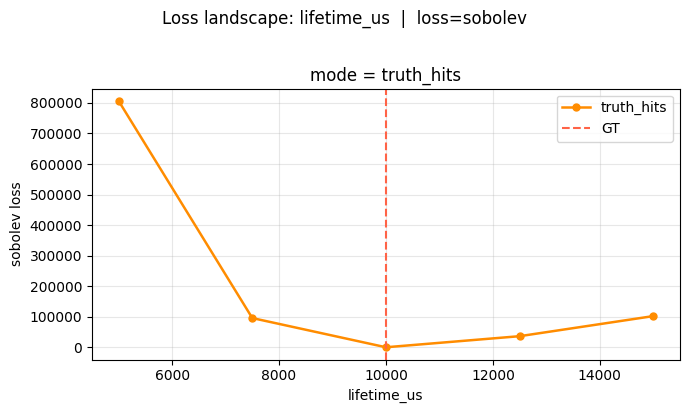

In [16]:
# =============================================================================
# OVERLAY: response vs truth_hits
# Skips 'response' mode if simulator was not built with differentiable=True.
# =============================================================================

has_diff = hasattr(simulator, '_forward_diff')
modes_to_run = ['response', 'truth_hits'] if has_diff else ['truth_hits']

if not has_diff:
    print("NOTE: simulator has no _forward_diff — skipping 'response' mode.")
    print("      To enable it, add differentiable=True, n_segments=TOTAL_PAD to the constructor.")

results = {}
for mode in modes_to_run:
    print(f'\n--- mode={mode} ---')
    results[mode] = sweep_parameter(
        simulator, deposits, base_params,
        param_name=PARAM,
        values=sweep_values,
        mode=mode,
        weights=weights,
        cfg=cfg,
        weight_type=LOSS_TYPE,
        verbose=True,
    )

colors = {'response': 'steelblue', 'truth_hits': 'darkorange'}
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 4), sharey=False, squeeze=False)

for ax, mode in zip(axes[0], results):
    L = results[mode]
    ax.plot(sweep_values, L, 'o-', color=colors[mode], ms=5, lw=1.8, label=mode)
    ax.axvline(default_val, color='tomato', ls='--', lw=1.5, label='GT')
    ax.set_xlabel(PARAM)
    ax.set_ylabel(f'{LOSS_TYPE} loss')
    ax.set_title(f'mode = {mode}')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Loss landscape: {PARAM}  |  loss={LOSS_TYPE}', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(f'plots/landscape_{PARAM}_both_modes.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# =============================================================================
# VISUALIZE RESPONSE SIGNALS — plot wire signals for a given SimParams
# =============================================================================

from tools.landscape import response_to_arrays

def plot_wire_deposits(sim, deps, sim_params, cfg):
    """Run process_event and plot wire signals for all (vol, plane) combinations.

    Works without differentiable=True — uses the standard production path.
    """
    response_signals, _, _ = sim.process_event(deps, sim_params=sim_params,
                                                key=jax.random.PRNGKey(0))
    det_arrays = response_to_arrays(response_signals, cfg)

    n_vols   = cfg.n_volumes
    n_planes = cfg.volumes[0].n_planes
    keys     = sorted(det_arrays.keys())   # (vi, pi) in order

    fig, axes = plt.subplots(n_vols, n_planes,
                             figsize=(5 * n_planes, 3.5 * n_vols),
                             squeeze=False)
    for vi, pi in keys:
        arr = np.array(det_arrays[(vi, pi)])   # (num_wires, num_time)
        ax  = axes[vi][pi]
        plane_name = cfg.plane_names[vi][pi]
        im = ax.imshow(arr, aspect='auto', origin='lower',
                       interpolation='nearest',
                       vmin=0, vmax=np.percentile(arr, 99))
        ax.set_title(f'Vol {vi} — {plane_name}-plane')
        ax.set_xlabel('Time tick')
        ax.set_ylabel('Wire')
        plt.colorbar(im, ax=ax, label='Charge')

    fig.suptitle('Wire signals', fontsize=13)
    plt.tight_layout()
    plt.show()

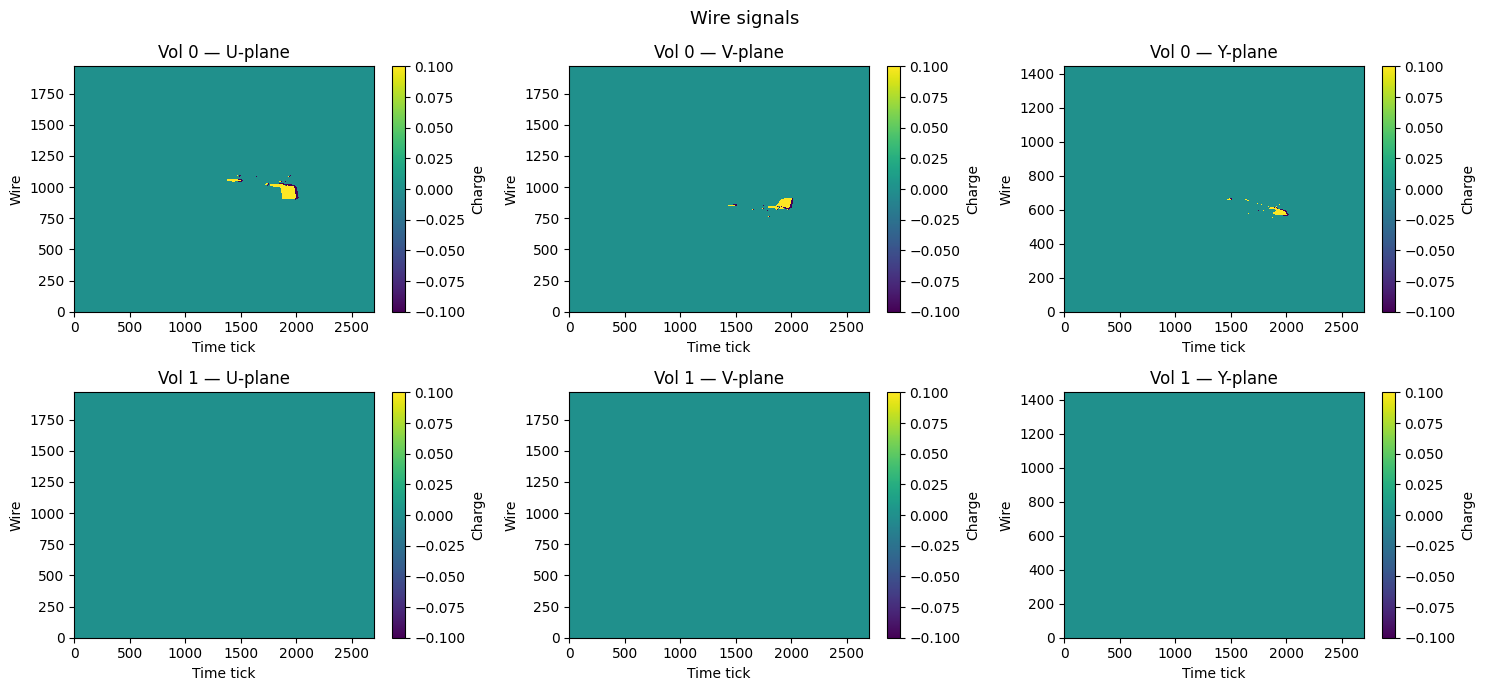

In [18]:
# Uses simulator_diff (must have been set up in the setup cell above)
plot_wire_deposits(simulator, deposits, base_params, cfg)

In [19]:
# =============================================================================
# CAPTURE SIGNALS FOR GRADIENT IMAGES
# =============================================================================
# Compute dSignal/d(lifetime_us) via central finite differences at the GT value.
# Uses process_event (response signals, full detector output).
# Runs 3 forward passes: τ = 7500, 10000, 12500 μs.

from tools.landscape import response_to_arrays

def _response_at_lifetime(tau):
    """Return per-plane detector arrays for a given lifetime value."""
    params = base_params._replace(lifetime_us=jnp.array(float(tau)))
    response_signals, _, _ = simulator.process_event(
        deposits, sim_params=params, key=jax.random.PRNGKey(42))
    det_arrays = response_to_arrays(response_signals, cfg)
    det = {}
    for (vi, pi), arr in det_arrays.items():
        name = cfg.plane_names[vi][pi]
        det[name] = det.get(name, 0) + np.array(arr.T)  # (time, wire)
    return det

tau_lo, tau_gt, tau_hi = 7500.0, 10000.0, 12500.0
delta_tau = 2500.0

print(f'Running τ = {tau_lo:.0f} μs...')
det_lo = _response_at_lifetime(tau_lo)
print(f'Running τ = {tau_gt:.0f} μs...')
det_gt = _response_at_lifetime(tau_gt)
print(f'Running τ = {tau_hi:.0f} μs...')
det_hi = _response_at_lifetime(tau_hi)

# Central-difference gradient: dS/dτ  [units: charge per μs]
plane_names = ['U', 'V', 'Y']
gradients = {
    p: (det_hi[p] - det_lo[p]) / (2.0 * delta_tau)
    for p in plane_names
}
print('Done. Gradient arrays computed.')


Running τ = 7500 μs...
Running τ = 10000 μs...
Running τ = 12500 μs...
Done. Gradient arrays computed.


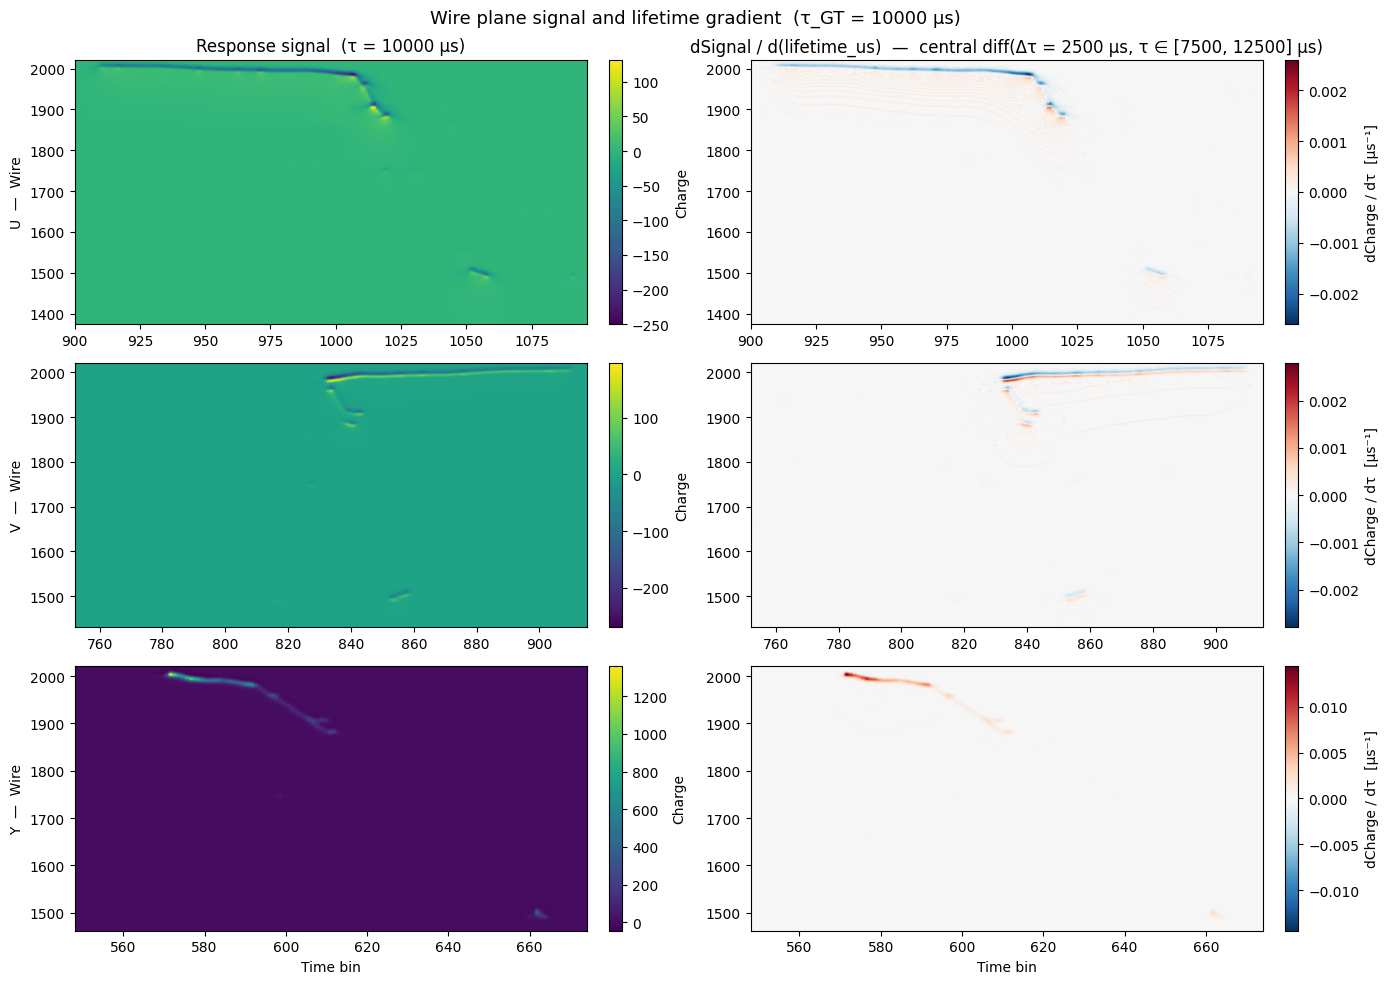

In [20]:
# =============================================================================
# PLOT: SIGNAL AT GT  +  dSignal/d(lifetime_us)
# =============================================================================

def _nonzero_bbox(arr):
    nz = np.argwhere(arr != 0)
    if len(nz) == 0:
        return None
    (y0, x0), (y1, x1) = nz.min(axis=0), nz.max(axis=0)
    return int(x0), int(x1), int(y0), int(y1)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for row, pname in enumerate(plane_names):
    gt   = det_gt[pname]
    grad = gradients[pname]

    bbox = _nonzero_bbox(gt)
    if bbox:
        x0, x1, y0, y1 = bbox
        x_range, y_range = [x0, x1], [y0, y1]
    else:
        x_range = [0, gt.shape[1]]
        y_range = [0, gt.shape[0]]

    ext = [0, gt.shape[1], 0, gt.shape[0]]

    # Left: GT signal
    ax = axes[row, 0]
    im = ax.imshow(gt, aspect='auto', origin='lower', extent=ext, cmap='viridis')
    ax.set_xlim(x_range); ax.set_ylim(y_range)
    if row == 0:
        ax.set_title(f'Response signal  (τ = {tau_gt:.0f} μs)')
    ax.set_ylabel(f'{pname}  —  Wire')
    if row == 2:
        ax.set_xlabel('Time bin')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Charge')

    # Right: gradient
    ax = axes[row, 1]
    absmax = float(np.abs(grad).max()) or 1.0
    im = ax.imshow(grad, aspect='auto', origin='lower', extent=ext,
                   cmap='RdBu_r', vmin=-absmax, vmax=absmax)
    ax.set_xlim(x_range); ax.set_ylim(y_range)
    if row == 0:
        ax.set_title(
            f'dSignal / d(lifetime_us)  —  central diff'
            f'(Δτ = {delta_tau:.0f} μs, τ ∈ [{tau_lo:.0f}, {tau_hi:.0f}] μs)')
    if row == 2:
        ax.set_xlabel('Time bin')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='dCharge / dτ  [μs⁻¹]')

fig.suptitle(
    f'Wire plane signal and lifetime gradient  '
    f'(τ_GT = {tau_gt:.0f} μs)',
    fontsize=13)
fig.tight_layout()
fig.savefig(f'plots/gradient_{PARAM}.png', dpi=150, bbox_inches='tight')
plt.show()
